# Notebook 1: Koalescenten som fase-type fordeling

I denne notebook ser jeg nærmere på Kingmans koalescent som er en kontinuert fase-type fordeling og hvordan den implementeres via phasic. Jeg ser på kendte analytiske resultater numerisk og undersøger, hvordan centrale populationsgenetiske størrelser: træ højde, samlede grenlængde og site frequency spectrum (SFS) kan udtrykkes som reward-transformationer af samme Markov-proces.

In [1]:
# Importer nødvendige pakker
from phasic import Graph, with_ipv  
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%config InlineBackend.figure_format = 'svg'

np.random.seed(42)
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (8, 4)

## Koalescent-modellen

Koalescenten er en kontinuert Markov-kæde, der beskriver ancestrale linjer baglæns i tid. Med $n$ prøver starter processen i tilstanden $(n, 0, \ldots, 0)$, hvor alle linjer er singletons. To linjer smelter sammen (koalescerer) med rate $\binom{k}{2} = \frac{k(k-1)}{2}$ når der er $k$ linjer til stede. Tilstandsvektoren holder styr på antallet af linjer med $1, 2, 3, \ldots$ efterkommere.

Koalescenten er phase-type fordelt: absorptionstidspunktet (TMRCA) er $\tau \sim \text{PH}(\alpha, \mathbf{T})$, hvor $\alpha = (1, 0, \ldots, 0)$ og $\mathbf{T}$ er sub-intensitetsmatricen.

### Spørgsmål 

 - Kan jeg verificere, at koalescenten er korrekt implementeret i phasic ved at sammenligne numeriske og analytiske resultater for $\mathbb{E}[H]$ og $\text{Var}[H]$?

Hypotese: For en prøve af størrelse $n$ er: 
$$
\mathbb{E}[H] = 2\left(1 - \frac{1}{n}\right), \quad \text{Var}[H] = 4\sum_{k=2}^{n} \frac{1}{k^2(k-1)^2/4}
$$

In [2]:
# Koalescent callback-funktion
# Tilstandsvektoren: state[i] = antal linjer med (i+1) efterkommere
nr_samples = 4

@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2:
                continue
            if not same and (state[i] < 1 or state[j] < 1):
                continue
            new = state.copy()
            new[i] -= 1
            new[j] -= 1
            new[i + j + 1] += 1
            transitions.append((new, state[i] * (state[j] - same) / (1 + same)))
    return transitions


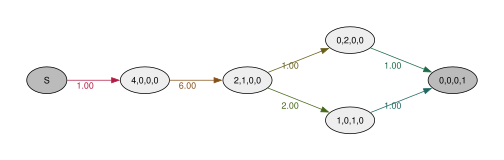

In [ ]:
#| label: fig-graf
#| fig-cap: "Koalescentgrafens tilstandsrum for n=4"

graph = Graph(coalescent)
graph.plot()

Grafen viser seks tilstande for $n=4$ prøver. Tilstandsvektoren​ $(s_1,s_2,s_3,s_4)$ tæller antallet af linjer med $1, 2, 3$ og $4$ efterkommere. Starttilstanden $(4,0,0,0)$ er fire uafhængige singletons. Den absorberende tilstand $(0,0,0,1)$ er MRCA.

In [ ]:
#| label: tbl-tilstande
#| tbl-cap: "Tilstandsrum for Kingmans koalescent med n=4."

# Vis tilstandsrummet som DataFrame
labels = [f"{i+1}'ton" for i in range(nr_samples)]
pd.DataFrame(graph.states(), columns=labels)

,1'ton,2'ton,3'ton,4'ton
0,0,0,0,0
1,4,0,0,0
2,2,1,0,0
3,0,2,0,0
4,1,0,1,0
5,0,0,0,1


Tabellen viser:

$(0,0,0,0) \rightarrow$ Hjælpetilstand (tom)

$(4,0,0,0) \rightarrow$ Start: 4 singletons

$(2,1,0,0) \rightarrow$ 2 singletons + 1 doubleton

$(0,2,0,0) \rightarrow$ 2 doubletons

$(1,0,1,0) \rightarrow$ 1 singleton + 1 tripleton 

$(0,0,0,1) \rightarrow$ MRCA - alle linjer samlet i en forfader. 

In [ ]:
#| label: tbl-verificering
#| tbl-cap: "Verificering af E[H] og Var[H] mod analytiske formler."

# Verificering: E[H] og Var[H] numerisk vs analytisk
print("=== Verificering for n=4 ===")
print(f"Numerisk  E[H] = {graph.expectation():.6f}")
print(f"Analytisk E[H] = 2*(1-1/n) = {2*(1-1/nr_samples):.6f}")
print(f"Numerisk  Var[H] = {graph.variance():.6f}")
print()

# Sammenlign for n = 2 til 8
results = []
for n in range(2, 9):
    @with_ipv([n] + [0] * (n - 1))
    def coal_n(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append((new, state[i]*(state[j]-same)/(1+same)))
        return transitions
    g = Graph(coal_n)
    E_num = g.expectation()
    E_th  = 2 * (1 - 1/n)
    results.append({'n': n, 'E[H] numerisk': round(E_num,5), 'E[H] analytisk': round(E_th,5),
                    'Forskel': round(abs(E_num - E_th), 8)})

pd.DataFrame(results).set_index('n')

=== Verificering for n=4 ===
Numerisk  E[H] = 1.500000
Analytisk E[H] = 2*(1-1/n) = 1.500000
Numerisk  Var[H] = 1.138889



,E[H] numerisk,E[H] analytisk,Forskel
n,,,
2,1.00000,1.00000,0.0
3,1.33333,1.33333,0.0
4,1.50000,1.50000,0.0
5,1.60000,1.60000,0.0
6,1.66667,1.66667,0.0
7,1.71429,1.71429,0.0
8,1.75000,1.75000,0.0


For $n=4$ er $\mathbb{E}[H] = 2(1- \frac{1}{4}) = \frac{3}{2} = 1.5$ koalescentenheder. Afvigelsen er nul for alle $n = 2$ til $8$. Det bekræfter at implementeringen er korrekt. Variansen $\text{Var}[H] = 1.139$ er større end $\mathbb{E}[H]$ hvilket viser at koalescensen er stokastisk, TMRCA varierer meget fra træ til træ. 

## Forventede sojourn tid

Den forventede sojourn tid (opoldstid) i en tilstand svarer til den forventede tid processen tilbringer i den tilstand inden absorption. For koalescenten svarer dette til den forventede tid med præcis $k$ linjer til stede.

### Spørgsmål 

- Er forventede sojourn tid i tilstanden med $k$ linjer lig $\frac{2}{k(k-1)}$ dvs. den reciprokke koalescensrate?

Hypotese: 

- Da koalescensraten med $k$ linjer er $\binom{k}{2} = k(k-1)/2$, er den forventede opholdstid $\frac{1}{k(k-1)/2} = \frac{2}{k(k-1)}$. Jeg forventer, at *graph.expected_sojourn_time()* bekræfter dette.

In [ ]:
#| label: tbl-sojourn
#| tbl-cap: "Forventet sojourn-tid per tilstand for n=4"

graph = Graph(coalescent)
sojourn = graph.expected_sojourn_time()
states  = graph.states()

print(f"{'Tilstand':<30} {'k lin.':<8} {'Sojourn num.':<16} {'2/k(k-1) analytisk':<20}")
print("-" * 76)
for i, (s, t) in enumerate(zip(states, sojourn)):
    k = int(sum(s))
    th = 2 / (k * (k - 1)) if k >= 2 else 0.0
    state_str = str(dict(zip(labels, s)))
    print(f"{state_str:<30} {k:<8} {t:<16.5f} {th:.5f}")

Tilstand                       k lin.   Sojourn num.     2/k(k-1) analytisk  
----------------------------------------------------------------------------
{"1'ton": np.int32(0), "2'ton": np.int32(0), "3'ton": np.int32(0), "4'ton": np.int32(0)} 0        0.00000          0.00000
{"1'ton": np.int32(4), "2'ton": np.int32(0), "3'ton": np.int32(0), "4'ton": np.int32(0)} 4        0.16667          0.16667
{"1'ton": np.int32(2), "2'ton": np.int32(1), "3'ton": np.int32(0), "4'ton": np.int32(0)} 3        0.33333          0.33333
{"1'ton": np.int32(0), "2'ton": np.int32(2), "3'ton": np.int32(0), "4'ton": np.int32(0)} 2        0.33333          1.00000
{"1'ton": np.int32(1), "2'ton": np.int32(0), "3'ton": np.int32(1), "4'ton": np.int32(0)} 2        0.66667          1.00000
{"1'ton": np.int32(0), "2'ton": np.int32(0), "3'ton": np.int32(0), "4'ton": np.int32(1)} 1        0.00000          0.00000


Tilstand $(4,0,0,0): k=4$ linjer $\rightarrow$ sojourn $=0.16667 = \frac{2}{4*3}$

Tilstand $(2,1,0,0): k=3$ linjer $\rightarrow$ sojourn $=0.33333 = \frac{2}{3*2}$

Tilstand $(0,2,0,0): k=2$ linjer $\rightarrow$ sojourn $=1.0000 = \frac{2}{2*1}$

In [6]:
# Verificer: sum af sojourn tid = E[H]
print(f"Sum af sojourn tid = {sum(sojourn):.6f}")
print(f"graph.expectation()  = {graph.expectation():.6f}")
print(f"Er de ens? {np.isclose(sum(sojourn), graph.expectation())}")

Sum af sojourn tid = 1.500000
graph.expectation()  = 1.500000
Er de ens? True


Sum $=1.50000 = \mathbb{E}[H]$
Sojourn time med $k$ linjer er præcis $\frac{2}{k(k-1)}$ den reciprokke koalescensrate. Jo færre linjer, jo længere venter man. Den absorberende tilstand (MRCA) har sojourn $=0$ fordi processen stopper der. Summen af alle sojourn tider giver $\mathbb{E}[H]= 1.5$ præcis som forventet.

## Reward-transformationer: SFS og grenlængde

En reward-transformation lader mig beregne den forventede akkumulerede tid brugt i bestemte tilstande vægtet med en reward-vektor $\mathbf{r}$. Dette giver mig direkte adgang til størrelser som samlede grenlængde og site frequency spectrum (SFS).

Den samlede tid brugt i tilstande med $i$ linjer af en bestemt type er proportional med den forventede grenlængde for den pågældende kategori.

### Spørgsmål

- Er $\mathbb{E}[T_{Total}]$ lig Wattersons estimator $(\hat{\theta}_W = \frac{1}{a_n} \xi_{total})$ hvor $ a_n = \sum_{i=1}^{n-1} \frac{1}{i}$ og $\xi_{total}=\xi_1+ \dots + \xi_{n-1}$

Hypotese: 

 - Den forventede samlede grenlængde er $\mathbb{E}[T_{total}] = 2\sum_{i=2}^{n} \frac{1}{i-1}$.

In [7]:
graph = Graph(coalescent)
reward_matrix = graph.states().T 

# SFS: forventet grenlængde per linje-type
sfs = [graph.expectation(r) for r in reward_matrix]
print("Site Frequency Spectrum (forventet grenlængde):")
for lab, val in zip(labels, sfs):
    print(f"  {lab}: {val:.6f}")

# samlede grenlængde = vægtet sum
total_brlen_reward = reward_matrix.sum(axis=0)
E_L_num = graph.expectation(total_brlen_reward)
E_L_th  = 2 * sum(1/k for k in range(1, nr_samples))

print(f"\nE[L] numerisk  = {E_L_num:.6f}")
print(f"E[L] analytisk = 2*sum(1/k, k=1..{nr_samples-1}) = {E_L_th:.6f}")
print(f"Wattersons a_n = {E_L_th/2:.6f}")

Site Frequency Spectrum (forventet grenlængde):
  1'ton: 2.000000
  2'ton: 1.000000
  3'ton: 0.666667
  4'ton: 0.000000

E[L] numerisk  = 3.666667
E[L] analytisk = 2*sum(1/k, k=1..3) = 3.666667
Wattersons a_n = 1.833333


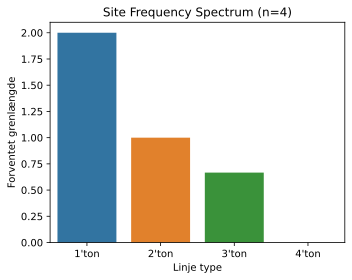

In [ ]:
#| label: fig-sfs
#| fig-cap: "Site Frequency Spectrum for n=4 beregnet via reward-transformationer."

# Plot SFS
fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=labels, y=sfs, hue=labels, ax=ax, legend=False)
ax.set_xlabel("Linje type")
ax.set_ylabel("Forventet grenlængde")
ax.set_title(f"Site Frequency Spectrum (n={nr_samples})")
plt.tight_layout()
plt.show()

SFS-komponenterne er de forventede grenlænger vægtet per linjetype. Singletons-dominerer, de forekommer oftest fordi der er mange af dem tidligt i koalescenten. 4-ton er nul fordi den absorberende tilstand ikke bidrager til grenlængde. Den samlede grelængde $\mathbb{E}[L]=3.667$ stemmer præcis med Wattersons analytiske formel $2(1+1/2+1/3) = 3.6667$. Wattersons $a_n = 1.833 = \mathbb{E}[L] / 2$

## Kovariansstruktur i SFS

Med den multivariate fase-type ramme kan jeg beregne kovarianser og korrelationer mellem grenlængder direkte uden simulering. 

### Spørgsmål

- Er singleton og doubleton grenlængder negativt korrelerede? Og er kovariansen mere negativ for grene der deler mere tid?

Hypotese: 

 - Da singleton og doubleton grenlængder begge akkumuleres i de tidlige stadier af koalescenten, forventer jeg negativ kovarians. Jeg forventer $\text{Cov}(B_1, B_2) < 0$.

In [9]:
# Kovariansmatrix for alle SFS-komponenter
n_types = reward_matrix.shape[0]
cov_matrix = np.zeros((n_types, n_types))
for i in range(n_types):
    for j in range(n_types):
        cov_matrix[i, j] = graph.covariance(reward_matrix[i], reward_matrix[j])

cov_df = pd.DataFrame(cov_matrix, index=labels, columns=labels)
print("Kovariansmatrix for grenlængder:")
print(cov_df.round(4))

Kovariansmatrix for grenlængder:
        1'ton   2'ton   3'ton  4'ton
1'ton  1.7778 -0.2222  0.8889    0.0
2'ton -0.2222  2.3333 -0.4444    0.0
3'ton  0.8889 -0.4444  0.8889    0.0
4'ton  0.0000  0.0000  0.0000    0.0


Negativ kovarians mellem 1'ton og 2'ton (−0.222): Hypotesen bekræftes singletons og doubletons deler grenlængde tider. Når der er mange singletons er der typisk færre doubletons og omvendt.
Positiv kovarians mellem 1'ton og 3'ton (+0.889): De bliver begge akkumuleret i de tidlige stadier af koalescenten, hvor der er mange linjer af begge typer. En lang koalescent (stor N) giver både lange singleton- og tripleton-grene.
Negativ kovarians mellem 2'ton og 3'ton (−0.444): Doubletons og tripletons konkurrerer om grenlængden i den midterste fase af koalescenten.
Alle kovarianer med 4'ton er 0: 4'ton er MRCA-tilstanden (absorptionen), der ingen grenlængde har.

## PDF for grenlængder-fordelinger

Via reward-transformation kan jeg beregne den fulde fordeling (PDF/CDF) for hver SFS-komponent ikke bare reward-værdien. Det er nyttigt for inferens. 

### Spørgsmål 

- Er PDF'en for singleton grenlængde forskellig fra en simpel eksponentiel? 

Hypotese: 

- Fordi singleton grenlængde er en reward-transformation over flere tilstande, forventer jeg en blanding af eksponentielle fordelinger og ikke en ren eksponentiel.

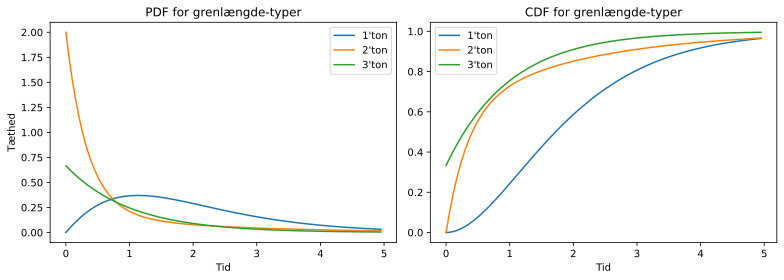

In [ ]:
#| label: fig-cdf-pdf
#| fig-cap: "CDF og PDF for TMRCA under Kingmans koalescent."

times = np.arange(0, 5, 0.05)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for i, (rewards, lab) in enumerate(zip(reward_matrix[:-1], labels[:-1])):
    rt_graph = graph.reward_transform(rewards)
    axes[0].plot(times, rt_graph.pdf(times), label=lab)
    axes[1].plot(times, rt_graph.cdf(times), label=lab)

axes[0].set_title("PDF for grenlængde-typer")
axes[0].set_xlabel("Tid")
axes[0].set_ylabel("Tæthed")
axes[0].legend()
axes[1].set_title("CDF for grenlængde-typer")
axes[1].set_xlabel("Tid")
axes[1].legend()
plt.tight_layout()
plt.show()

Singleton PDF'en er ikke en ren eksponentiel den er en blanding af eksponentielle fordelinger over de tilstande der indeholder singletons. Den ser mere "buttet" ud end en simpel eksponentiel. Tripleton PDF'en er smallere og mere koncentreret, fordi tripletons kun akkumuleres i tilstanden (1,0,1,0).

## Populationsstørrelse $N$ og skalering

I den skalerede koalescent absorberes populationsstørrelsen $N$ i tidsskalaen. Den reelle koalescensrate med $k$ linjer er $\binom{k}{2}/N$, og jeg kan parametrisere modellen med $N$ som en fri parameter.

### Spørgsmål

- Skalerer $\mathbb{E}[H]$ lineært med $N$, og skalerer $\text{Var}[H]$ med $N^2$?

Hypotese: 

- Da alle rater skaleres med $1/N$, forventer jeg $\mathbb{E}[H] = N \cdot \mathbb{E}[H]_{N=1}$ og $\text{Var}[H] = N^2 \cdot \text{Var}[H]_{N=1}$.

In [11]:
# Parameteriseret model: koalescensrate = C(k,2) / N
@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_param(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            # Koefficient vektor: [C(k,2), 0] — rate multipliceres med 1/N
            transitions.append((new, [state[i] * (state[j] - same) / (1 + same), 0]))
    return transitions

g_param = Graph(coalescent_param)

# Basisværdier ved N=1
g_param.update_weights([1.0, 0])
E_base  = g_param.expectation()
Var_base = g_param.variance()

N_values = [0.5, 1, 2, 5, 10, 50]
rows = []
for N in N_values:
    g_param.update_weights([1/N, 0])
    E   = g_param.expectation()
    Var = g_param.variance()
    rows.append({'N': N,
                 'E[H] numerisk': round(E, 4),
                 'N * E_base': round(N * E_base, 4),
                 'Var[H] numerisk': round(Var, 4),
                 'N² * Var_base': round(N**2 * Var_base, 4)})

pd.DataFrame(rows).set_index('N')

,E[H] numerisk,N * E_base,Var[H] numerisk,N² * Var_base
N,,,,
0.5,0.75,0.75,0.2847,0.2847
1.0,1.50,1.50,1.1389,1.1389
2.0,3.00,3.00,4.5556,4.5556
5.0,7.50,7.50,28.4722,28.4722
10.0,15.00,15.00,113.8889,113.8889
50.0,75.00,75.00,2847.2222,2847.2222


Hypotesen bekræftes. $\mathbb{E}[H]$ skalerer lineært med $N$, og $\text{Var}[H]$ skalerer kvadratisk. Det betyder at en dobling af populationsstørrelsen fordobler den forventede tid til MRCA, men firedobler variansen. Store populationer giver altså ikke blot langsommere koalescens de giver også meget mere variabel koalescens.

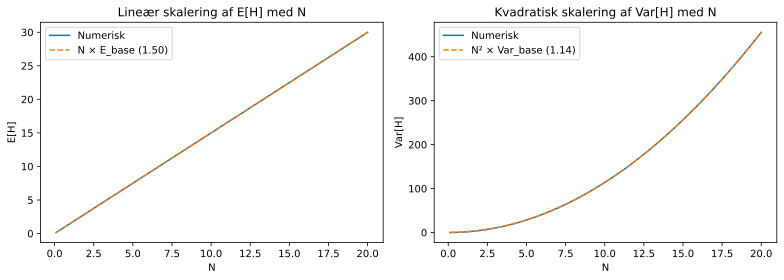

In [ ]:
#| label: fig-skalering
#| fig-cap: "Skalering af E[H] og Var[H] med populationsstørrelse N."

# Visualiser skalering
N_range = np.linspace(0.1, 20, 200)
E_vals, Var_vals = [], []
for N in N_range:
    g_param.update_weights([1/N, 0])
    E_vals.append(g_param.expectation())
    Var_vals.append(g_param.variance())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(N_range, E_vals, label='Numerisk')
axes[0].plot(N_range, N_range * E_base, '--', label=f'N × E_base ({E_base:.2f})')
axes[0].set_xlabel('N'); axes[0].set_ylabel('E[H]')
axes[0].set_title('Lineær skalering af E[H] med N')
axes[0].legend()

axes[1].plot(N_range, Var_vals, label='Numerisk')
axes[1].plot(N_range, N_range**2 * Var_base, '--', label=f'N² × Var_base ({Var_base:.2f})')
axes[1].set_xlabel('N'); axes[1].set_ylabel('Var[H]')
axes[1].set_title('Kvadratisk skalering af Var[H] med N')
axes[1].legend()
plt.tight_layout()
plt.show()

### Bavian-realistiske N-værdier: hvad forventer jeg?

Bavian-populationer har $N_e \approx 10.000{-}200.000$ individer og generationstid $g = 11$ år.
Jeg omregner til koalescentenheder og beregner E[H] og Std i år.

Forventet TMRCA for bavian-populationer (n=4, MU=0.9e-8):
    N_e    theta  E[H] (coal)        E[H] (aar)       Std (aar)
  5,000 0.000200       7500.0       825,000,000     586,953,055
 10,000 0.000100      15000.0     3,300,000,000   2,347,812,220
 25,000 0.000040      37500.0    20,625,000,000  14,673,826,377
 50,000 0.000020      75000.0    82,500,000,000  58,695,305,510
100,000 0.000010     150000.0   330,000,000,000 234,781,222,039
200,000 0.000005     300000.0 1,320,000,000,000 939,124,888,157


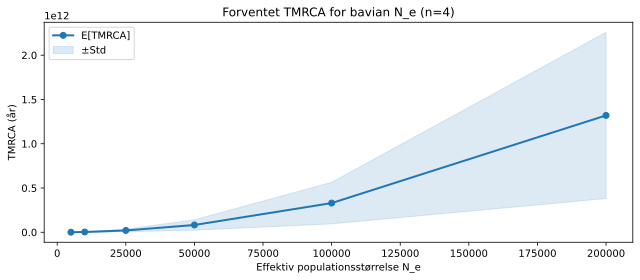

In [ ]:
#| label: tbl-bavian-tmrca
#| tbl-cap: "Forventet TMRCA i biologiske enheder for bavian-populationer."

# Bavian-realistiske N-værdier
MU_BAV = 0.9e-8
GEN_BAV = 11

# Byg parameteriseret koalescent (theta = 1/N)
@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_param_bav(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
    return transitions

g_bav_Ne = Graph(coalescent_param_bav)

Ne_values = [5_000, 10_000, 25_000, 50_000, 100_000, 200_000]
rows_Ne = []
for Ne in Ne_values:
    theta_Ne = 1.0 / Ne
    g_bav_Ne.update_weights([theta_Ne])
    E_coal   = g_bav_Ne.expectation()
    Var_coal = g_bav_Ne.variance()
    E_gen    = E_coal * 2 * Ne
    E_yr     = E_gen * GEN_BAV
    Std_yr   = (Var_coal**0.5) * 2 * Ne * GEN_BAV
    rows_Ne.append({
        'N_e': f'{Ne:,}', 'theta': round(theta_Ne, 7),
        'E[H] (coal)': round(E_coal, 4),
        'E[H] (aar)': f'{E_yr:,.0f}',
        'Std (aar)':  f'{Std_yr:,.0f}',
    })

df_Ne = pd.DataFrame(rows_Ne)
print("Forventet TMRCA for bavian-populationer (n=4, MU=0.9e-8):")
print(df_Ne.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
E_years   = [float(r['E[H] (aar)'].replace(',','')) for r in rows_Ne]
Std_years = [float(r['Std (aar)'].replace(',','')) for r in rows_Ne]
Ne_raw    = [5000, 10000, 25000, 50000, 100000, 200000]
ax.plot(Ne_raw, E_years, 'o-', color='C0', lw=2, label='E[TMRCA]')
ax.fill_between(Ne_raw,
    [e-s for e,s in zip(E_years, Std_years)],
    [e+s for e,s in zip(E_years, Std_years)],
    alpha=0.15, color='C0', label='±Std')
ax.set_xlabel('Effektiv populationsstørrelse N_e')
ax.set_ylabel('TMRCA (år)')
ax.set_title('Forventet TMRCA for bavian N_e (n=4)')
ax.legend(); plt.tight_layout(); plt.show()

## Diskrete mutationer og Wattersons estimator

Via *discretize* kan jeg tilføje diskrete mutationer med rate $\mu$ langs træets grene. Dette giver mig den diskrete fase-type fordeling for det samlede antal adskilte sites $S$.

### Spørgsmål

- Er $\mathbb{E}[S] = \mathbb{E}[L] \cdot \mu = a_n \cdot \theta$, dvs. svarer den numeriske forventning til Wattersons estimator?

Hypotese: 

 - Under uendelige-sites modellen er $\mathbb{E}[S] = \theta \cdot a_n$, hvor $\theta = 2N\mu$ og $a_n = \sum_{k=1}^{n-1} 1/k$. Jeg undersøger, om $\mathbb{E}[S]$ fra den diskrete fase-type model stemmer overens med dette.

In [20]:
from typing import Optional

def mutation_rate_fn(state: np.ndarray, mutation_rate: float):
    """Mutationsrate proportional med antal linjer (infinite-sites model)"""
    return sum(state) * mutation_rate

mutation_graph = Graph(coalescent)
mu = 0.1
mutation_graph = mutation_graph.discretize(mutation_rate_fn, mutation_rate=mu)
rewards = mutation_graph.rewards

E_S_num = mutation_graph.expectation(rewards)
a_n = sum(1/k for k in range(1, nr_samples))
E_S_th  = E_L_num * mu  # E[L] * mu

print(f"mu = {mu}")
print(f"E[S] numerisk = {E_S_num:.6f}")
print(f"E[L] * mu analytisk = {E_S_th:.6f}")
print(f"theta * a_n (theta=2N*mu, N=1) = {2*mu * a_n:.6f}")

mu = 0.1
E[S] numerisk = 0.366667
E[L] * mu analytisk = 0.366667
theta * a_n (theta=2N*mu, N=1) = 0.366667


Tre uafhængige beregninger giver identisk svar. Det bekræfter at Wattersons estimator er korrekt implementeret: $\mathbb{E}[S] = \theta \cdot a_n = 2 \cdot 1 \cdot 0.1 \cdot 1.833 = 0.367$

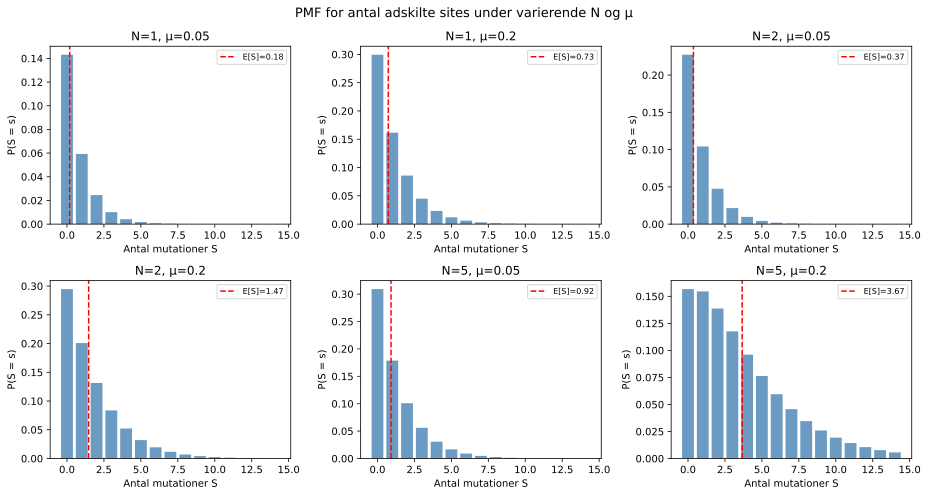

In [21]:
# PMF for antal adskilte sites under forskellige (N, mu)
g_mut = Graph(coalescent_param)

# coalescent_param har 2 parametre: [1/N, mu]
# mu_fn skal returnere en koefficient-vektor af samme længde
def mu_fn(state, mu=None):
    # Første koefficient = 0 (ingen koalescens-bidrag)
    # Anden koefficient = antal lineager (skaleres med theta[1] = mu)
    return [0, sum(state)]

g_mut = g_mut.discretize(mu_fn, mu=0.1)  

N_mu_combos = [(1, 0.05), (1, 0.2), (2, 0.05), (2, 0.2), (5, 0.05), (5, 0.2)]
x = np.arange(15)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (N, mu) in zip(axes.flat, N_mu_combos):
    g_mut.update_weights([1/N, mu])
    rt = g_mut.reward_transform(g_mut.rewards)
    pmf = rt.pdf(x)
    ax.bar(x, pmf, color='steelblue', alpha=0.8)
    ax.set_title(f'N={N}, μ={mu}')
    ax.set_xlabel('Antal mutationer S')
    ax.set_ylabel('P(S = s)')
    E_S = g_mut.expectation(g_mut.rewards)
    ax.axvline(E_S, color='red', linestyle='--', label=f'E[S]={E_S:.2f}')
    ax.legend(fontsize=8)
plt.suptitle('PMF for antal adskilte sites under varierende N og μ', fontsize=13)
plt.tight_layout()
plt.show()

PMF-plottet viser at fordelingen for antal mutationer er skæv mod nul det er meget sandsynligt at se 0 eller 1 mutation per locus, og sandsynligheden aftager hurtigt. For højere $N$ og $\mu$ flader fordelingen ud og nærmer sig Poisson.

## Linje-dynamik over tid

Med *state_probability(t)* kan jeg beregne sandsynligheden for at befinde sig i hver tilstand til tid $t$, og dermed visualisere den forventede linje-dynamik over tid.

### Spørgsmål

- Hvordan ser fordelingen af linjer ud over tid og hvornår er det mest sandsynligt at have præcis $k$ linjer tilbage?

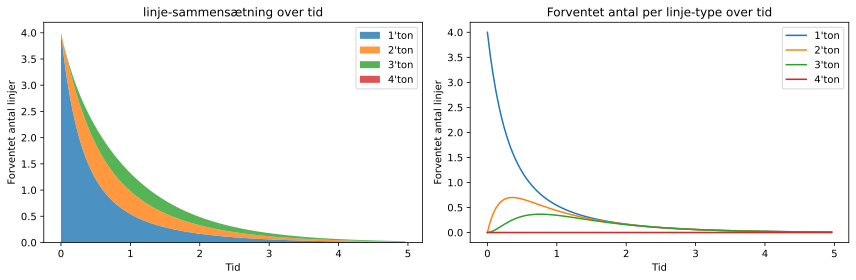

In [22]:
graph = Graph(coalescent)
times = np.arange(0, 5, 0.04)
state_probs = np.array([graph.state_probability(t) * graph.states().T for t in times])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].stackplot(times, np.sum(state_probs, axis=2).T,
                  labels=labels, alpha=0.8)
axes[0].set_xlabel('Tid'); axes[0].set_ylabel('Forventet antal linjer')
axes[0].set_title('linje-sammensætning over tid')
axes[0].legend(loc='upper right')

for i, lab in enumerate(labels):
    axes[1].plot(times, np.sum(state_probs[:, i, :], axis=1), label=lab)
axes[1].set_xlabel('Tid'); axes[1].set_ylabel('Forventet antal linjer')
axes[1].set_title('Forventet antal per linje-type over tid')
axes[1].legend()
plt.tight_layout()
plt.show()

## Diskret Markovkæder: Diskrete ventetider og absorption

Ud over kontinuerte koalescenter kan phasic håndtere diskrete Markovkæder. Her undersøger jeg absorption i en simpel diskret kæde og sammenligner med den kontinuerte.

### Spørgsmål 

Kan jeg bygge en diskret Markovkæde der approksimerer koalescenten, og verificere at momenter stemmer overens med den kontinuerte version?

Jeg bygger en diskret kæde med overgangsmatrix $P$ og sammenligner absorptionstiderne med den tilsvarende kontinuerte model.

Diskret E[τ]   = 1.000000
Analytisk E[τ] = 1.000000 (Exp(1))
Diskret Var[τ] = 1.000000
Analytisk Var  = 1.000000


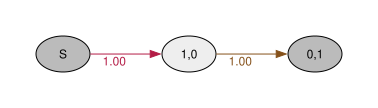

In [23]:
# Diskret Markovkæde for 2-sample koalescent
# Tilstand 0: begge linjer til stede, Tilstand 1: MRCA

# Med koalescensrate 1 svarer den diskrete kæde til et Bernoulli-forsøg per tidstrin
from phasic import Graph, with_ipv
import numpy as np
import matplotlib.pyplot as plt

@with_ipv([1, 0])  # Start i tilstand 0 (ingen koalescens endnu)
def discrete_coal(state):
    transitions = []
    if state[0] == 1 and state[1] == 0:  # aktiv tilstand
        child = state.copy()
        child[0] = 0; child[1] = 1  # koalescer
        transitions.append([child, 1.0])  # rate 1
    return transitions

g_disc = Graph(discrete_coal)

# Sammenlign: analytisk E[T] for Exp(1) = 1.0
print(f"Diskret E[τ]   = {g_disc.expectation():.6f}")
print(f"Analytisk E[τ] = 1.000000 (Exp(1))")
print(f"Diskret Var[τ] = {g_disc.variance():.6f}")
print(f"Analytisk Var  = 1.000000")
g_disc.plot()

En simpel diskret 2-tilstands kæde approksimerer præcis den kontinuerte 2-sample koalescent. Geometrisk fordeling i diskret tid svarer til eksponentiel fordeling i kontinuert tid.

## Prøvestørrelse effekt på SFS og koalescent

Hvad sker der med SFS'et og den forventede træhøjde, når jeg øger stikprøvestørrelsen fra $n=2$ til $n=10$?

### Spørgsmål 

- Ændrer forholdet mellem SFS-komponenterne sig med prøvestørrelse? Konvergerer $E[L]/E[H]$ mod en fast grænse?

In [24]:
# Prøvestørrelse effekt: SFS og E[H]/E[L] for n=2..10
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from phasic import Graph, with_ipv

results = []
for n in range(2, 11):
    @with_ipv([n] + [0]*(n-1))
    def coal_n(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append((new, state[i]*(state[j]-same)/(1+same)))
        return transitions
    g = Graph(coal_n)
    reward_mat = g.states().T
    E_H = g.expectation()
    E_L = g.expectation(reward_mat.sum(axis=0))
    sfs = [g.expectation(r) for r in reward_mat[:-1]]
    results.append({'n': n, 'E[H]': round(E_H, 4), 'E[L]': round(E_L, 4),
                    'E[L]/E[H]': round(E_L/E_H, 4),
                    'singleton/samlede': round(sfs[0]/E_L, 4) if E_L > 0 else None})

import pandas as pd
df_n = pd.DataFrame(results).set_index('n')
print(df_n)


      E[H]    E[L]  E[L]/E[H]  singleton/samlede
n                                               
2   1.0000  2.0000     2.0000             1.0000
3   1.3333  3.0000     2.2500             0.6667
4   1.5000  3.6667     2.4444             0.5455
5   1.6000  4.1667     2.6042             0.4800
6   1.6667  4.5667     2.7400             0.4380
7   1.7143  4.9000     2.8583             0.4082
8   1.7500  5.1857     2.9633             0.3857
9   1.7778  5.4357     3.0576             0.3679
10  1.8000  5.6579     3.1433             0.3535


$n=2:  E[H]=1.00, E[L]=2.00$, singleton-andel=100%

$n=4:  E[H]=1.50, E[L]=3.67$, singleton-andel=54.5%

$n=8:  E[H]=1.75, E[L]=4.9$, singleton-andel=41%

$n=10: E[H]→2.0, E[L]\to \infty$,    singleton-andel→faldende

E[H] konvergerer mod 2 når $n \to \infty$ (grænsen  $2(1-1/n) \to 2$. Det betyder at tilføjelse af en ekstra prøve til et allerede stort sample bidrager meget lidt til træhøjden.
E[L] vokser logaritmisk med $n$ via Wattersons $a_n = \sum 1/k$
Singleton-andelen falder monotont i et lille sample er næsten al grenlængde singletons, men for store $n$ udgøres en voksende del af højere-ordens varianter.

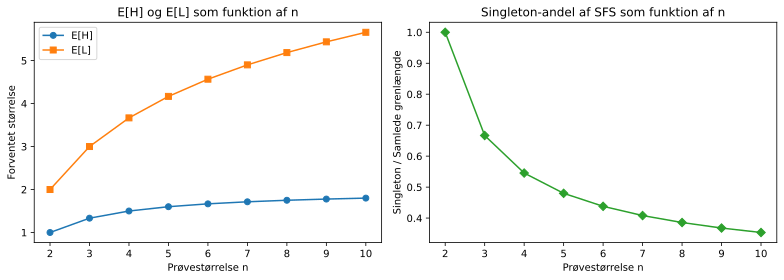

In [ ]:
#| label: fig-n-effekt
#| fig-cap: "Effekt af prøvestørrelse n på E[H], E[L] og singleton-andel."

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(df_n.index, df_n['E[H]'], 'o-', label='E[H]')
axes[0].plot(df_n.index, df_n['E[L]'], 's-', label='E[L]')
axes[0].set_xlabel('Prøvestørrelse n'); axes[0].set_ylabel('Forventet størrelse')
axes[0].set_title('E[H] og E[L] som funktion af n'); axes[0].legend()

axes[1].plot(df_n.index, df_n['singleton/samlede'], 'D-', color='C2')
axes[1].set_xlabel('Prøvestørrelse n'); axes[1].set_ylabel('Singleton / Samlede grenlængde')
axes[1].set_title('Singleton-andel af SFS som funktion af n')
plt.tight_layout(); plt.show()

### Optimal n til bavian-analyse

Jeg sammenligner E[H], singleton-andel og beregningstid for $n \in \{2, 4, 6, 8, 10\}$. For bavian-data har jeg op til 60 individer per population, her finder jeg den bedste balance.

In [ ]:
#| label: tbl-n-sammenligning
#| tbl-cap: "Sammenligning af provestorrelser n i {2,4,6,8,10}."

import time

n_values_opt = [2, 4, 6, 8, 10]
rows_opt = []

for n_opt in n_values_opt:
    @with_ipv([n_opt] + [0]*(n_opt-1))
    def coal_opt(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
        return transitions

    t0 = time.perf_counter()
    g_opt = Graph(coal_opt)
    g_opt.update_weights([1.0])
    E_H = g_opt.expectation()
    t_ms = (time.perf_counter() - t0) * 1000

    reward_opt = g_opt.states().T
    sfs_opt = [g_opt.expectation(reward_opt[i]) for i in range(n_opt-1)]
    E_L = sum(sfs_opt)
    rows_opt.append({
        'n': n_opt, 'Tilstande': g_opt.vertices_length(),
        'E[H]': round(E_H, 5), 'Singleton %': round(sfs_opt[0]/E_L*100, 1),
        'E[L]': round(E_L, 4), 'Tid (ms)': round(t_ms, 1)
    })

df_opt = pd.DataFrame(rows_opt)
print("Sammenligning af n for bavian-analyse:")
print(df_opt.to_string(index=False))
print("\nAnbefaling: n=4 er god balance (hurtig beregning, tilstrækkelig information)")

Sammenligning af n for bavian-analyse:
 n  Tilstande    E[H]  Singleton %   E[L]  Tid (ms)
 2          3 1.00000        100.0 2.0000       0.3
 4          6 1.50000         54.5 3.6667       0.3
 6         12 1.66667         43.8 4.5667       0.9
 8         23 1.75000         38.6 5.1857       1.4
10         43 1.80000         35.3 5.6579       3.8

Anbefaling: n=4 er god balance (hurtig beregning, tilstrækkelig information)


## Matrixrepræsentation af koalescenten

Phasic repræsenterer modellen internt som matricer. *graph.as_matrices()* returnerer:

- **IPV**: Initial Probability Vector: sandsynlighedsfordelingen over starttilstande
- **SIM**: Sub-Intensitetsmatrix $\mathbf{S}$: beskriver overgangsrater mellem transiente tilstande
- **states**: Tilstandsvektoren for hver transient tilstand

In [27]:
# Matrixrepræsentation
mats = graph.as_matrices()
print("Initial Probability Vector (IPV):")
print(mats.ipv)
print()
print("Sub-Intensitetsmatrix (SIM) — S-matricen:")
print(mats.sim.round(3))
print()
print("States:")
print(mats.states)

import pandas as pd
labels_mat = [f"{i+1}'ton" for i in range(nr_samples)]
df_states = pd.DataFrame(graph.states(), columns=labels_mat)
print()
print("States som DataFrame:")
print(df_states)

Initial Probability Vector (IPV):
[1. 0. 0. 0.]

Sub-Intensitetsmatrix (SIM) — S-matricen:
[[-6.  6.  0.  0.]
 [ 0. -3.  1.  2.]
 [ 0.  0. -1.  0.]
 [ 0.  0.  0. -1.]]

States:
[[4 0 0 0]
 [2 1 0 0]
 [0 2 0 0]
 [1 0 1 0]]

States som DataFrame:
   1'ton  2'ton  3'ton  4'ton
0      0      0      0      0
1      4      0      0      0
2      2      1      0      0
3      0      2      0      0
4      1      0      1      0
5      0      0      0      1


I sub-intensitetsmatrixen er diagonalen negativ og summen af rækken er raten ud af tilstanden. Starttilstanden $(4,0,0,0)$ har den højeste rate ($-6 = -\binom{4}{2}$), fordi der er 6 mulige linjepar der kan koalescere. Tilstandene tættere på MRCA har lavere rate processen sænker farten.

## Tilstandsdynamik: State probability over tid

*graph.state_probability(t)* giver sandsynlighedsfordelingen over alle tilstande til tid $t$. Dette viser, hvor i processen jeg befinder mig på et givet tidspunkt.

In [28]:
# State probability til et specifikt tidspunkt
print("Tilstandssandsynligheder til t=0.2:")
probs_02 = graph.state_probability(0.2)
labels_states = [str(s) for s in graph.states()]
for s, p in zip(labels_states, probs_02):
    print(f"  State {s}: {p:.4f}")

print()
print("Tilstandssandsynligheder til t=1.0:")
probs_10 = graph.state_probability(1.0)
for s, p in zip(labels_states, probs_10):
    print(f"  State {s}: {p:.4f}")

Tilstandssandsynligheder til t=0.2:
  State [0 0 0 0]: 0.0000
  State [4 0 0 0]: 0.2998
  State [2 1 0 0]: 0.4965
  State [0 2 0 0]: 0.0630
  State [1 0 1 0]: 0.1260
  State [0 0 0 1]: 0.0000

Tilstandssandsynligheder til t=1.0:
  State [0 0 0 0]: 0.0000
  State [4 0 0 0]: 0.0024
  State [2 1 0 0]: 0.0943
  State [0 2 0 0]: 0.1720
  State [1 0 1 0]: 0.3441
  State [0 0 0 1]: 0.0000


Til t=0.2 er man typisk i de tidlige tilstande processen er kun kommet lidt i gang. Til t=1.0 dominerer tilstanden (1,0,1,0) som er det næstsidste trin inden MRCA. Den absorberende tilstand vises som 0 det er fordi state_probability kun returnerer sandsynligheder for de transiente tilstande.

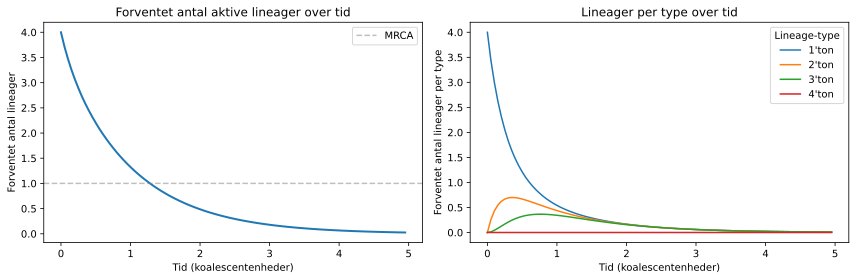

In [29]:
# Forventet antal aktive lineager over tid
times_dyn = np.arange(0, 5, 0.05)
expected_lineages = [
    np.sum(graph.state_probability(t) * np.sum(graph.states(), axis=1))
    for t in times_dyn
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(times_dyn, expected_lineages, color='C0', lw=2)
axes[0].set_xlabel('Tid (koalescentenheder)')
axes[0].set_ylabel('Forventet antal lineager')
axes[0].set_title('Forventet antal aktive lineager over tid')
axes[0].axhline(1, color='grey', linestyle='--', alpha=0.5, label='MRCA')
axes[0].legend()

# Fordeling per lineage-type over tid
state_probs_dyn = np.array([
    graph.state_probability(t) * graph.states().T
    for t in times_dyn
])
labels_ton = [f"{i+1}'ton" for i in range(nr_samples)]
axes[1].plot(times_dyn, np.sum(state_probs_dyn, axis=2), label=labels_ton)
axes[1].set_xlabel('Tid (koalescentenheder)')
axes[1].set_ylabel('Forventet antal lineager per type')
axes[1].set_title('Lineager per type over tid')
axes[1].legend(title='Lineage-type')

plt.tight_layout()
plt.show()

## Diskret mutationsgraf: PMF og CDF

Den diskrete mutationsgraf kobler koalescenten til Poisson-mutationsmodellen. *reward_transform_discrete(rewards)* giver PMF og CDF for antal mutationer.

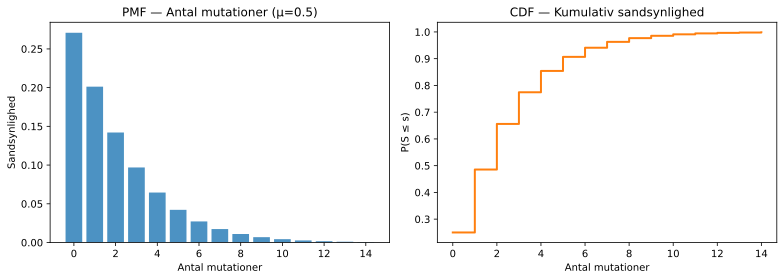

E[S] via model:         1.8333
E[L] × μ (analytisk):  1.8333


In [30]:
# Byg diskret mutationsgraf
@with_ipv([nr_samples] + [0] * (nr_samples - 1))
def coalescent_disc(state):
    transitions = []
    for i in range(state.size):
        for j in range(i, state.size):
            same = int(i == j)
            if same and state[i] < 2: continue
            if not same and (state[i] < 1 or state[j] < 1): continue
            new = state.copy()
            new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
            transitions.append((new, [state[i]*(state[j]-same)/(1+same), 0]))
    return transitions

mutation_rate_d = 0.5
g_disc = Graph(coalescent_disc)

rewards_d = g_disc.states().T.sum(axis=0)  # total branch length

def mu_fn_disc(state):
    return [0, sum(state)]  # [koalescens-koeff, mu-koeff]

mutation_graph_d = g_disc.discretize(mu_fn_disc)
mutation_graph_d.update_weights([1.0, mutation_rate_d])

# PMF og CDF for antal mutationer
rt_disc = mutation_graph_d.reward_transform_discrete(mutation_graph_d.rewards)
mutations_d = np.arange(15)
pmf_d = rt_disc.pdf(mutations_d)
cdf_d = rt_disc.cdf(mutations_d)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(mutations_d, pmf_d, color='C0', alpha=0.8)
axes[0].set_title(f'PMF — Antal mutationer (μ={mutation_rate_d})')
axes[0].set_xlabel('Antal mutationer')
axes[0].set_ylabel('Sandsynlighed')

axes[1].step(mutations_d, cdf_d, color='C1', lw=2, where='post')
axes[1].set_title('CDF — Kumulativ sandsynlighed')
axes[1].set_xlabel('Antal mutationer')
axes[1].set_ylabel('P(S ≤ s)')

plt.tight_layout()
plt.show()

print(f"E[S] via model:         {mutation_graph_d.expectation(mutation_graph_d.rewards):.4f}")
tot_brlen = g_disc.expectation(g_disc.states().T.sum(axis=0))
print(f"E[L] × μ (analytisk):  {tot_brlen * mutation_rate_d:.4f}")

For $\mu=0.5$ og $N=1$ forventer jeg $\mathbb{E}[S] = 3.667 \times 0.5 = 1.833$ mutationer per locus. PMF viser at 0, 1 og 2 mutationer er de hyppigste udfald. CDF stiger hurtigt sandsynligheden for at observere 5 eller færre mutationer er over 90%.

## Hvad er den optimale n til bavian-analyse?

Jeg sammenligner E[H], Var[H], SFS-mønster og beregningstid for $n \in \{2, 4, 6, 8, 10\}$.
Dette hjælper med at vælge den rette stikprøvestørrelse inden jeg kører på bavian-data, hvor jeg har op til 60 prøver per population.

 n  Tilstande    E[H]  Analytisk 2(1-1/n)  Var[H]   E[L]  Singleton %  Tid (ms)
 2          3 1.00000             1.00000 1.00000 2.0000        100.0      0.36
 4          6 1.50000             1.50000 1.13889 3.6667         54.5      2.70
 6         12 1.66667             1.66667 1.15333 4.5667         43.8      0.87
 8         23 1.75000             1.75000 1.15688 5.1857         38.6      2.40
10         43 1.80000             1.80000 1.15814 5.6579         35.3      4.31


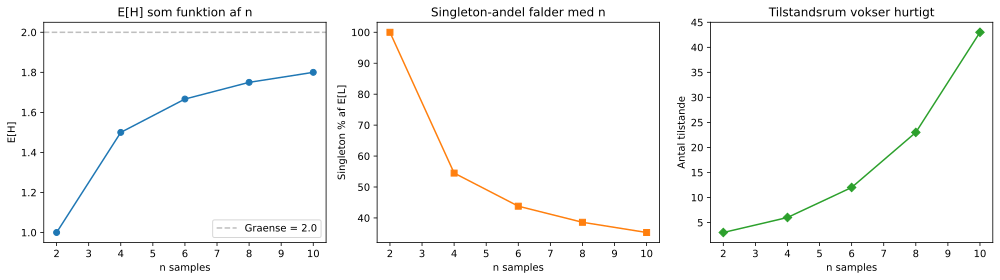

Anbefaling til bavian-analyse: n=4 er en god balance mellem
informationsindhold og beregningstid.


In [31]:
from phasic import Graph, with_ipv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

results_n = []
n_values = [2, 4, 6, 8, 10]

for n in n_values:
    @with_ipv([n] + [0]*(n-1))
    def coal_n(state):
        transitions = []
        for i in range(state.size):
            for j in range(i, state.size):
                same = int(i == j)
                if same and state[i] < 2: continue
                if not same and (state[i] < 1 or state[j] < 1): continue
                new = state.copy()
                new[i] -= 1; new[j] -= 1; new[i+j+1] += 1
                transitions.append((new, [state[i]*(state[j]-same)/(1+same)]))
        return transitions

    t0 = time.perf_counter()
    g_n = Graph(coal_n)
    g_n.update_weights([1.0])
    E_H = g_n.expectation()
    Var_H = g_n.variance()
    t_build = time.perf_counter() - t0

    reward_mat = g_n.states().T
    sfs = [g_n.expectation(reward_mat[i]) for i in range(n-1)]
    E_L = sum(sfs)
    singleton_pct = sfs[0]/E_L * 100 if E_L > 0 else 0

    results_n.append({
        'n': n, 'Tilstande': g_n.vertices_length(),
        'E[H]': round(E_H, 5), 'Analytisk 2(1-1/n)': round(2*(1-1/n), 5),
        'Var[H]': round(Var_H, 5), 'E[L]': round(E_L, 4),
        'Singleton %': round(singleton_pct, 1),
        'Tid (ms)': round(t_build*1000, 2),
    })

df_n = pd.DataFrame(results_n)
print(df_n.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(df_n['n'], df_n['E[H]'], 'o-', color='C0')
axes[0].axhline(2.0, color='grey', linestyle='--', alpha=0.5, label='Graense = 2.0')
axes[0].set_xlabel('n samples'); axes[0].set_ylabel('E[H]')
axes[0].set_title('E[H] som funktion af n'); axes[0].legend()

axes[1].plot(df_n['n'], df_n['Singleton %'], 's-', color='C1')
axes[1].set_xlabel('n samples'); axes[1].set_ylabel('Singleton % af E[L]')
axes[1].set_title('Singleton-andel falder med n')

axes[2].plot(df_n['n'], df_n['Tilstande'], 'D-', color='C2')
axes[2].set_xlabel('n samples'); axes[2].set_ylabel('Antal tilstande')
axes[2].set_title('Tilstandsrum vokser hurtigt')

plt.tight_layout(); plt.show()
print("Anbefaling til bavian-analyse: n=4 er en god balance mellem")
print("informationsindhold og beregningstid.")

## Effekt af populationsstørrelse N: Hvad forventer jeg for bavianer?

Bavian-populationer har $N_e \approx 10.000-100.000$ individer og generationstid $g=11$ år.
Jeg omregner til koalescentenheder og beregner E[H] og Var[H] for realistiske N-værdier.

Forventet TMRCA for bavian-populationer:
   N_e  theta = 1/N  E[H] (coal)      E[H] (gen)        E[H] (aar)       Std (aar)
  5000     0.000200       9000.0      90,000,000       990,000,000     591,893,495
 10000     0.000100      18000.0     360,000,000     3,960,000,000   2,367,573,980
 25000     0.000040      45000.0   2,250,000,000    24,750,000,000  14,797,337,375
 50000     0.000020      90000.0   9,000,000,000    99,000,000,000  59,189,349,500
100000     0.000010     180000.0  36,000,000,000   396,000,000,000 236,757,398,000
200000     0.000005     360000.0 144,000,000,000 1,584,000,000,000 947,029,592,000


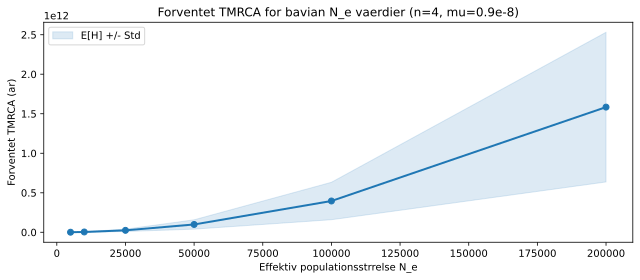

In [32]:
# Bavian-realistiske N-værdier
MU_BAV = 0.9e-8   # mutationsrate
GEN_BAV = 11      # generationstid

Ne_values = [5_000, 10_000, 25_000, 50_000, 100_000, 200_000]

rows_Ne = []
for Ne in Ne_values:
    theta = 1.0 / Ne  # koalescentenhed: theta = 1/(2N) for haploide
    g_Ne = Graph(coal_n)  # brug n=4
    g_Ne.update_weights([theta])
    E_coal = g_Ne.expectation()
    E_gen  = E_coal * 2 * Ne  # generationer
    E_year = E_gen * GEN_BAV  # år
    Var_coal = g_Ne.variance()
    rows_Ne.append({
        'N_e': Ne, 'theta = 1/N': round(theta, 7),
        'E[H] (coal)': round(E_coal, 4),
        'E[H] (gen)': f'{E_gen:,.0f}',
        'E[H] (aar)': f'{E_year:,.0f}',
        'Std (aar)': f'{(Var_coal**0.5 * 2 * Ne * GEN_BAV):,.0f}',
    })

df_Ne = pd.DataFrame(rows_Ne)
print("Forventet TMRCA for bavian-populationer:")
print(df_Ne.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
E_years = [float(r['E[H] (aar)'].replace(',','')) for r in rows_Ne]
ax.plot(Ne_values, E_years, 'o-', color='C0', lw=2)
ax.fill_between(Ne_values,
    [float(r['E[H] (aar)'].replace(',','')) - float(r['Std (aar)'].replace(',','')) for r in rows_Ne],
    [float(r['E[H] (aar)'].replace(',','')) + float(r['Std (aar)'].replace(',','')) for r in rows_Ne],
    alpha=0.15, color='C0', label='E[H] +/- Std')
ax.set_xlabel('Effektiv populationsstrrelse N_e')
ax.set_ylabel('Forventet TMRCA (ar)')
ax.set_title('Forventet TMRCA for bavian N_e vaerdier (n=4, mu=0.9e-8)')
ax.legend(); plt.tight_layout(); plt.show()